In [1]:
#load packages
import numpy as np
import xarray as xr
import math
import csv

import matplotlib.pyplot as plt
%matplotlib inline

import os
import pandas as pd
import cmocean
import matplotlib.gridspec as gridspec

from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes

# import gsw_xarray as gsw_xr # seawater calculations - might not need this one
import gsw as gsw
## mapping packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyproj import Transformer, Geod
from shapely.geometry import LineString, Point
from scipy.signal import savgol_filter
from scipy.interpolate import griddata

In [2]:
cd /g/data/jk72/deg581/seqom/analysis/notebooks

/g/data/jk72/deg581/seqom/analysis/notebooks


In [3]:
#define functions
def inpolygon(xq, yq, xv, yv):
    from matplotlib import path
    shape = xq.shape
    xq = xq.reshape(-1)
    yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)

from xgcm import Grid

# map u,v to rho points
def ROMSmetricsAndGrid(ds):
    ds = ds.rename({'eta_u': 'eta_rho', 'xi_v': 'xi_rho', 'xi_psi': 'xi_u', 'eta_psi': 'eta_v'})

    coords={'X':{'center':'xi_rho', 'inner':'xi_u'}, 
        'Y':{'center':'eta_rho', 'inner':'eta_v'}, 
        'Z':{'center':'s_rho', 'outer':'s_w'}}

    grid = Grid(ds, coords=coords, periodic=[])

    print('making pm/pn metrics')
    ds['pm_v'] = grid.interp(ds.pm, 'Y')
    ds['pn_u'] = grid.interp(ds.pn, 'X')
    ds['pm_u'] = grid.interp(ds.pm, 'X')
    ds['pn_v'] = grid.interp(ds.pn, 'Y')
    ds['pm_psi'] = grid.interp(grid.interp(ds.pm, 'Y'),  'X') # at psi points (eta_v, xi_u) 
    ds['pn_psi'] = grid.interp(grid.interp(ds.pn, 'X'),  'Y') # at psi points (eta_v, xi_u)
    print('making dx/dy')
    ds['dx'] = 1/ds.pm
    ds['dx_u'] = 1/ds.pm_u
    ds['dx_v'] = 1/ds.pm_v
    ds['dx_psi'] = 1/ds.pm_psi

    ds['dy'] = 1/ds.pn
    ds['dy_u'] = 1/ds.pn_u
    ds['dy_v'] = 1/ds.pn_v
    ds['dy_psi'] = 1/ds.pn_psi

#     ds['dz'] = grid.diff(ds.z_w, 'Z', boundary='fill')
#     ds['dz_w'] = grid.diff(ds.z_rho, 'Z', boundary='fill')
#     ds['dz_u'] = grid.interp(ds.dz, 'X')
#     ds['dz_w_u'] = grid.interp(ds.dz_w, 'X')
#     ds['dz_v'] = grid.interp(ds.dz, 'Y')
#     ds['dz_w_v'] = grid.interp(ds.dz_w, 'Y')

    ds['dA'] = ds.dx * ds.dy

    metrics = {
        ('X',): ['dx', 'dx_u', 'dx_v', 'dx_psi'], # X distances
        ('Y',): ['dy', 'dy_u', 'dy_v', 'dy_psi'], # Y distances
        # ('Z',): ['dz', 'dz_u', 'dz_v', 'dz_w', 'dz_w_u', 'dz_w_v'], # Z distances
        ('X', 'Y'): ['dA'] # Areas
    }
    grid = Grid(ds, coords=coords, metrics=metrics, periodic=[])

    return ds,grid



def add_zeros_to_4(date):
    if date<10:
        to_add = '000'
    elif date>9 & date<100:
        to_add = '00'
    elif date>99 & date < 1000:
        to_add = '0'
    else: 
        to_add = ''
    return to_add

def generateFileList(FilePath,prefix,datelist):
    filelist=[FilePath+prefix+add_zeros_to_4(datelist[0])+str(datelist[0])+'.nc']
    for dates in datelist[1:]:
        filenameToAppend=FilePath+prefix+add_zeros_to_4(dates)+str(dates)+'.nc'
        filelist.append(filenameToAppend)
    return filelist


def vorticity(u, v, grd):
    """
    compute the relative vorticity
    https://github.com/ESMG/pyroms/blob/python3/pyroms_toolbox/pyroms_toolbox/vorticity.py
    e.g. vorticity(ds.u.isel(s_rho=-1,ocean_time=1),ds.v.isel(s_rho=-1,ocean_time=1),grd)
    """

    dx = 1./grd.pm.values
    dy = 1./grd.pn.values

    #dx, dy at psi point
    dx = 0.5 * (dx[1:,:] + dx[:-1,:])
    dy = 0.5 * (dy[:,1:] + dy[:,:-1])

    vorticity = np.zeros(grd.mask_psi.shape)

    vorticity = 2 * (v[:,1:] - v[:,:-1]) / (dx[:,1:] + dx[:,:-1]) \
                - 2 * (u[1:,:] - u[:-1,:]) / (dy[1:,:] + dy[:-1,:])

    vorticity = np.ma.masked_where(grd.mask_psi == 0, vorticity)

def N2(rho, z, rho_0=1000.0):
    '''
    Return the stratification frequency
    
    Parameters
    ----------
    rho : array_like
        density [kg/m^3]
    z : array_like
        depths [m] (positive upward)
    
    Returns
    -------
    N2 : array_like
        Stratification frequency [1/s], where the vertical dimension (the
        first dimension) is one less than the input arrays.    
    '''
    rho = np.asarray(rho)
    z = np.asarray(z)
    assert rho.shape == z.shape, 'rho and z must have the same shape.'
    r_z = np.diff(rho, axis=0) / np.diff(z, axis=0)
    return -(9.8 / rho_0) * r_z


# Load Data

In [4]:
# load data file

grd = xr.open_dataset('/g/data/jk72/deg581/se-qld-setup/data/proc/seqld_1km_v1.7_grd.nc')

FilePath='/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/' #

prefix='roms_his_'
timeRange = [17,18]
datelist = np.array(range(timeRange[0],timeRange[1],1))


fl=generateFileList(FilePath,prefix,datelist)
print(fl)

# ds=loadOverlappedNetcdfFileList(filelist=fl,overlapDays=7)

ds = xr.open_mfdataset(fl,chunks = {'ocean_time':1}, data_vars='minimal', compat='override',coords='minimal',parallel='False',join='right')

print(ds.nbytes/1e9,'G')

ds = ds.drop_vars(['temp','salt','ubar_eastward','vbar_northward','rho','shflux','ssflux','sustr','svstr'])
print(ds.nbytes/1e9,'G')
ds

ds = ds.assign_coords({"lon_rho": grd.lon_rho})
ds = ds.assign_coords({"lat_rho": grd.lat_rho})

weights_area = (1/ds.pm)*(1/ds.pn)
weights_area.name = "weights"

print('making vertical coordinates')
Zo_rho = (ds.hc * ds.s_rho + ds.Cs_r * ds.h) / (ds.hc + ds.h)
z_rho =  ( ds.h) * Zo_rho
Zo_w = (ds.hc * ds.s_w + ds.Cs_w * ds.h) / (ds.hc + ds.h)
z_w = Zo_w * ( + ds.h) 
    
ds.coords['z_w0'] = z_w.where(ds.mask_rho, 0).transpose('s_w', 'eta_rho', 'xi_rho')
ds.coords['z_rho0'] = z_rho.where(ds.mask_rho, 0).transpose('s_rho', 'eta_rho', 'xi_rho')

ds['dz'] = (('s_rho', 'eta_rho', 'xi_rho'),np.diff(ds.z_w0,axis=0))

# dz_top = ds.z_w0.isel(s_w=-1) - ds.z_rho0.isel(s_rho=-1)
# dz_bottom = ds.z_rho0.isel(s_rho=0) - ds.z_w0.isel(s_w=0)
# # dz_interior = ds.z_rho0.diff('s_w')
# ds['dz_w'] = grid.diff(ds.z_rho0, 'Z')
# ds.dz_w.isel(s_w=-1)[:] = dz_top.values
# ds.dz_w.isel(s_w=0)[:] = dz_bottom.values

ds['dz'] = (('s_rho', 'eta_rho', 'xi_rho'),np.diff(ds.z_w0,axis=0))

ds, grid = ROMSmetricsAndGrid(ds)

# ds_17_again = ds

# ds.close()

['/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/roms_his_0017.nc']
39.617066672 G
24.319377932 G
making vertical coordinates
making pm/pn metrics
making dx/dy


In [5]:
ds.load()


<xarray.Dataset>
Dimensions:         (tracer: 2, boundary: 4, s_rho: 31, s_w: 32, Nuser: 1,
                     eta_rho: 720, xi_rho: 735, xi_u: 734, eta_v: 719,
                     ocean_time: 73)
Coordinates: (12/15)
  * s_rho           (s_rho) float64 -0.9839 -0.9516 ... -0.04839 -0.01613
  * s_w             (s_w) float64 -1.0 -0.9677 -0.9355 ... -0.06452 -0.03226 0.0
    x_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    y_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    y_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...              ...
    y_psi           (eta_v, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * ocean_time      (ocean_time) datetime64[ns] 2016-01-02 ... 2016-12-27
    lon_rho         (eta_rho, xi_rho) float64 151.5 151.5 151.5 ... 158.8 158.8
    lat_rho         (eta_rho, xi_rho) float64 -31.2 -31.2 ... -24.01 -24.01
    z_w0            (s_w, eta_rho, xi_rho) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    z_rho0          (s_rho, eta_rho, xi_rho) float64 0.0 0.0 ... -1.115 -1.116
Dimensions without coordinates: tracer, boundary, Nuser, eta_rho, xi_rho, xi_u,
                                eta_v
Data variables: (12/110)
    ntimes          int32 1051200
    ndtfast         int32 20
    dt              float64 30.0
    dtfast          float64 1.5
    dstart          datetime64[ns] 2000-01-01
    nHIS            int32 14400
    ...              ...
    dx_psi          (eta_v, xi_u) float64 951.2 951.2 ... 1.016e+03 1.016e+03
    dy              (eta_rho, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_u            (eta_rho, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_v            (eta_v, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_psi          (eta_v, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dA              (eta_rho, xi_rho) float64 1.058e+06 1.058e+06 ... 1.129e+06
Attributes: (12/35)
    file:              roms_his_0017.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             South-east Queensland, 1/100 (900m) degree resolution
    var_info:          ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /apps/openmpi/4.0.2/bin/mpif90
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            024x020
    history:           ROMS/TOMS, Version 4.2, Saturday - January 10, 2026 - ...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       SEQLD, ANA_BSFLUX, ANA_BTFLUX, ASSUMED_SHAPE, AVERAGES...

In [6]:
# load other model data

# /g/data/gb6/BRAN/BRAN2023/daily/ocean_u_2012_*.nc



# Need to chunk
ds_u = xr.open_mfdataset('/g/data/gb6/BRAN/BRAN2023/daily/ocean_u_2012_*.nc').sel(xu_ocean=slice(145,162)
                                                                                ,yu_ocean=slice(-32,-22)
                                                                                )
ds_v = xr.open_mfdataset('/g/data/gb6/BRAN/BRAN2023/daily/ocean_v_2012_*.nc').sel(xu_ocean=slice(145,162)
                                                                                ,yu_ocean=slice(-32,-22)
                                                                                )
ds_w = xr.open_mfdataset('/g/data/gb6/BRAN/BRAN2023/daily/ocean_w_2012_*.nc').sel(xt_ocean=slice(145,162)
                                                                                ,yt_ocean=slice(-32,-22)
                                                                                )

# ds_grid_bran = xr.open_dataset('/g/data/gb6/BRAN/BRAN2023/static/grid_spec.nc')


ds_u.load()
print('loaded u')
ds_v.load()
print('loaded v')
ds_w.load()
print('loaded w')




loaded u
loaded v
loaded w


## define time periods

In [7]:
winter_period=slice(30,40)
summer_period=slice(72,73)

winter_period_snapshot=slice(38,39)
summer_period_snapshot=slice(72,73)

# Do analyses

In [8]:
# FIRST ROMS

# potential vorticity
rel_vort = grid.derivative(ds.v, 'X') - grid.derivative(ds.u, 'Y')
rel_vort_norm = rel_vort / grid.interp(grid.interp(ds.f,'X'),'Y')

strain = np.sqrt( (grid.derivative(ds.u,'X') - grid.derivative(ds.v,'Y'))**2 + (grid.interp(grid.interp(grid.derivative(ds.u,'Y'),'X'),'Y') + grid.interp(grid.interp(grid.derivative(ds.v,'X'),'X'),'Y') )**2 )
strain_norm = strain / ds.f

# div = grid.derivative(ds.u, 'X') + grid.derivative(ds.v, 'Y')
# div_norm = div / ds.f

# #skew

# # skew_period = slice(25,40)
# skew_period = slice(0,73)


rel_vort_norm.load()
strain_norm.load()


# from scipy.stats import skew
# rel_vort_subset= rel_vort.isel(s_rho=-1).isel(ocean_time=skew_period)
# ntime, ny, nx = rel_vort_subset.shape
# zeta_skew_array = np.full((ny, nx), np.nan)# Preallocate result array
# for j in range(ny): # Loop over each grid point
#     print(j)
#     for i in range(nx):
#         series = rel_vort_subset[:, j, i]
#         if np.all(np.isnan(series)):
#             continue
#         zeta_skew_array[j, i] = skew(series, nan_policy='omit')
# zeta_skew = zeta_skew_array

# #mke
# u_bar = ds.u_eastward.mean("ocean_time")
# v_bar = ds.v_northward.mean("ocean_time")
# mke = 0.5*(u_bar**2 + v_bar**2)



# print('calc velocity anomalies')
# u_prime = ds.u_eastward - u_bar
# v_prime = ds.v_northward - v_bar

# print('calc eke')
# eke = 0.5*(u_prime**2 + v_prime**2)

print('calc vetical velocity variance')
w_var = ((ds.w - ds.w.mean(dim='ocean_time'))**2).mean(dim='ocean_time')



calc vetical velocity variance


In [9]:
# NOW BRAN
#  rel vorticity


R = 6371e3  # Earth radius [m]

lon = ds_u.xu_ocean
lat = ds_u.yu_ocean

# convert to radians
lon_rad = np.deg2rad(lon)
lat_rad = np.deg2rad(lat)

# grid spacing
dlon = lon_rad.diff('xu_ocean')
dlat = lat_rad.diff('yu_ocean')

# dx, dy on staggered dimensions
dx = R * np.cos(lat_rad) * dlon
dy = R * dlat

#correct for better broadcasting
dx = dx.broadcast_like(ds_v.v.isel(xu_ocean=slice(1, None)))
dy = dy.broadcast_like(ds_u.u.isel(yu_ocean=slice(1, None)))

# compute derivatives 
dvdx = ds_v.v.diff('xu_ocean') / dx
dudy = ds_u.u.diff('yu_ocean') / dy

# align grids (as deriv. removes a row/col)
dvdx, dudy = xr.align(dvdx, dudy, join='inner')

#rel vorticity
zeta = dvdx - dudy

# normalised rel vorticity
omega = 7.2921e-5  # Earth rotation rate

f = 2 * omega * np.sin(lat_rad)
f = f.broadcast_like(zeta)

zeta_norm = zeta / f

zeta_norm.load()

<xarray.DataArray (Time: 366, st_ocean: 51, yu_ocean: 100, xu_ocean: 170)>
array([[[[            nan,             nan,             nan, ...,
          -2.23745363e-01, -2.47857436e-01, -2.28707219e-01],
         [            nan,             nan,             nan, ...,
          -2.72200945e-01, -3.12959172e-01, -3.02410267e-01],
         [            nan,             nan,             nan, ...,
          -2.95174176e-01, -3.20636022e-01, -3.02551104e-01],
         ...,
         [            nan,             nan,             nan, ...,
          -4.77354028e-02, -3.06392165e-02, -1.35879714e-02],
         [            nan,             nan,             nan, ...,
          -4.75740709e-02, -3.37991604e-02, -2.35834006e-02],
         [            nan,             nan,             nan, ...,
          -6.46281168e-02, -4.62853130e-02, -3.61995172e-02]],

        [[            nan,             nan,             nan, ...,
          -2.23389217e-01, -2.47984204e-01, -2.29253324e-01],
         [            nan,             nan,             nan, ...,
          -2.72978279e-01, -3.13736523e-01, -3.03607737e-01],
         [            nan,             nan,             nan, ...,
          -2.95532312e-01, -3.21415138e-01, -3.02909272e-01],
...
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]])
Coordinates:
  * xu_ocean  (xu_ocean) float64 145.1 145.2 145.3 145.4 ... 161.8 161.9 162.0
  * yu_ocean  (yu_ocean) float64 -31.9 -31.8 -31.7 -31.6 ... -22.2 -22.1 -22.0
  * st_ocean  (st_ocean) float64 2.5 7.5 12.5 ... 2.895e+03 3.603e+03 4.509e+03
  * Time      (Time) datetime64[ns] 2012-01-01T12:00:00 ... 2012-12-31T12:00:00

In [10]:
# now calculate BRAN strain


#strain = np.sqrt( (grid.derivative(ds.u,'X') - grid.derivative(ds.v,'Y'))**2 + (grid.interp(grid.interp(grid.derivative(ds.u,'Y'),'X'),'Y') + grid.interp(grid.interp(grid.derivative(ds.v,'X'),'X'),'Y') )**2 )
#strain_norm = strain / ds.f

dudx = ds_u.u.diff('xu_ocean')/dx
dudy = ds_u.u.diff('yu_ocean')/dy
dvdx = ds_v.v.diff('xu_ocean')/dx
dvdy = ds_v.v.diff('yu_ocean')/dy

dudx, dudy, dvdx, dvdy = xr.align(dudx, dudy, dvdx, dvdy, join='inner')

strain_bran = np.sqrt( (dudx-dvdy)**2 + (dudy+dvdx)**2 )
f = 2 * omega * np.sin(lat_rad)
f = f.broadcast_like(strain_bran)
strain_bran_norm = strain_bran/f

strain_bran_norm.load()

<xarray.DataArray (Time: 366, st_ocean: 51, yu_ocean: 100, xu_ocean: 170)>
array([[[[        nan,         nan,         nan, ..., -0.03299777,
          -0.03489758, -0.03641405],
         [        nan,         nan,         nan, ..., -0.01971032,
          -0.02433678, -0.04249816],
         [        nan,         nan,         nan, ..., -0.06069866,
          -0.05992348, -0.03879096],
         ...,
         [        nan,         nan,         nan, ..., -0.05360793,
          -0.0641516 , -0.07970084],
         [        nan,         nan,         nan, ..., -0.03806261,
          -0.05328509, -0.06617383],
         [        nan,         nan,         nan, ..., -0.04519681,
          -0.05840617, -0.04958484]],

        [[        nan,         nan,         nan, ..., -0.03489973,
          -0.03645473, -0.03727381],
         [        nan,         nan,         nan, ..., -0.01962116,
          -0.02431864, -0.04265611],
         [        nan,         nan,         nan, ..., -0.06079223,
          -0.05990071, -0.03914669],
...
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]]]])
Coordinates:
  * xu_ocean  (xu_ocean) float64 145.1 145.2 145.3 145.4 ... 161.8 161.9 162.0
  * yu_ocean  (yu_ocean) float64 -31.9 -31.8 -31.7 -31.6 ... -22.2 -22.1 -22.0
  * st_ocean  (st_ocean) float64 2.5 7.5 12.5 ... 2.895e+03 3.603e+03 4.509e+03
  * Time      (Time) datetime64[ns] 2012-01-01T12:00:00 ... 2012-12-31T12:00:00

In [11]:
# now calculate bran verticalvelocity variance
w_var_bran = ((ds_w.w - ds_w.w.mean(dim='Time'))**2).mean(dim='Time')

# begin plotting

In [12]:
import pandas as pd # for labelling purposes


period_snapshot_1 = slice(38,39)
period_snapshot_2 = slice(56,57)
period_snapshot_3 = slice(72,73)


Text(0, 0.5, "$\\langle w'^2 \\rangle$")

<Figure size 640x480 with 0 Axes>

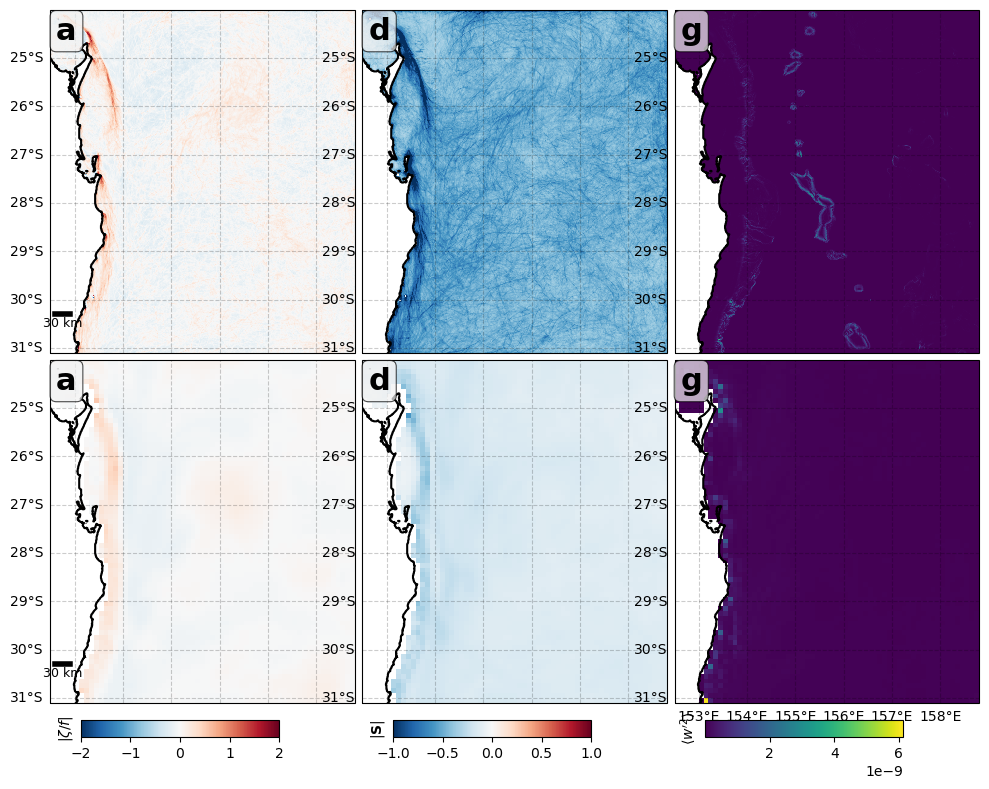

In [13]:
# snapshots of submeso diagnostics

plt.cla()
plt.clf()
fig = plt.figure(figsize=[12,9])
ax = None

gs = gridspec.GridSpec(nrows=2,ncols=3,wspace=0.02, hspace=0.02)

choose_depth=0

# OUR MODEL

##### Ro number
ax=fig.add_subplot(gs[0,0],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,rel_vort_norm.mean(dim='ocean_time').isel(s_rho=-1),cmap='RdBu_r',vmin=-2,vmax=2)
# ax.contour(grd.lon_psi,grd.lat_psi,rel_vort_norm.isel(s_rho=-1).isel(ocean_time=winter_period_snapshot).squeeze(),colors='k',linewidths=.5)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])
gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False

ax.text(0.019, 0.98, 'a', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))
# ax.text(0.019, 0.91, 'Ro', transform=ax.transAxes,fontsize=22, fontweight='normal', va='top')

central_lat = -27.5  # adjust for your map
scale_length_km = 30
deg_per_km = 1 / (111.32 * np.cos(np.radians(central_lat)))
scale_length_deg = scale_length_km * deg_per_km
lon0 = 152.6  # scale bar position
lat0 = -30.3
# Add scale bar
ax.plot([lon0, lon0 + scale_length_deg], [lat0, lat0],
        transform=ccrs.PlateCarree(), color='black', lw=4)
ax.text(lon0 + scale_length_deg / 2, lat0 + 0.002*lat0, '30 km',
        transform=ccrs.PlateCarree(), ha='center', va='top', fontsize=9)

# tt = ds.ocean_time.isel(ocean_time=period_snapshot_1).values[0]
# label = pd.to_datetime(tt).strftime('%B-%d')
# ax.set_title(label,fontsize=20)

##### strain
ax=fig.add_subplot(gs[0,1],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,strain_norm.isel(s_rho=-1).mean(dim='ocean_time').squeeze(),cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False
ax.text(0.019, 0.98, 'd', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))


##### <w'>
ax=fig.add_subplot(gs[0,2],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,w_var.isel(s_w=-1))#,cmap='cmo.rain_r',vmin=0,vmax=0.4e-3)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
ax.text(0.019, 0.98, 'g', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))

# BRAN MODEL

##### Ro number
ax=fig.add_subplot(gs[1,0],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,zeta_norm.mean(dim='Time').isel(st_ocean=0),cmap='RdBu_r',vmin=-2,vmax=2)
# ax.contour(grd.lon_psi,grd.lat_psi,rel_vort_norm.isel(s_rho=-1).isel(ocean_time=winter_period_snapshot).squeeze(),colors='k',linewidths=.5)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])
gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False

ax.text(0.019, 0.98, 'a', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))
# ax.text(0.019, 0.91, 'Ro', transform=ax.transAxes,fontsize=22, fontweight='normal', va='top')

central_lat = -27.5  # adjust for your map
scale_length_km = 30
deg_per_km = 1 / (111.32 * np.cos(np.radians(central_lat)))
scale_length_deg = scale_length_km * deg_per_km
lon0 = 152.6  # scale bar position
lat0 = -30.3
# Add scale bar
ax.plot([lon0, lon0 + scale_length_deg], [lat0, lat0],
        transform=ccrs.PlateCarree(), color='black', lw=4)
ax.text(lon0 + scale_length_deg / 2, lat0 + 0.002*lat0, '30 km',
        transform=ccrs.PlateCarree(), ha='center', va='top', fontsize=9)

# tt = ds.ocean_time.isel(ocean_time=period_snapshot_1).values[0]
# label = pd.to_datetime(tt).strftime('%B-%d')
# ax.set_title(label,fontsize=20)


cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.1,-0.1, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_ylabel(r'$|\zeta/f|$')#,fontsize=14)

##### strain
ax=fig.add_subplot(gs[1,1],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,strain_bran_norm.mean(dim='Time').isel(st_ocean=0),cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False
ax.text(0.019, 0.98, 'd', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))


cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.1,-0.1, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_ylabel(r'$|\mathbf{S}|$')#,fontsize=14)

##### <w'>
ax=fig.add_subplot(gs[1,2],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,w_var_bran.isel(sw_ocean=0))#,cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
ax.text(0.019, 0.98, 'g', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))

cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.1,-0.1, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_ylabel(r"$\langle w'^2 \rangle$")#,fontsize=14)

######




# now do same over top 100m

In [14]:
# ROMS
dz_top = ds.z_w0.isel(s_w=-1) - ds.z_rho0.isel(s_rho=-1)
dz_bottom = ds.z_rho0.isel(s_rho=0) - ds.z_w0.isel(s_w=0)
# dz_interior = ds.z_rho0.diff('s_w')
ds['dz_w'] = grid.diff(ds.z_rho0, 'Z')
ds.dz_w.isel(s_w=-1)[:] = dz_top.values
ds.dz_w.isel(s_w=0)[:] = dz_bottom.values

top_mask = ds.z_w0>=-100

w_var_topX = ((w_var * ds.dz_w).where(top_mask).sum(dim='s_w', skipna=True) /  ds.dz_w.where(top_mask).sum(dim='s_w', skipna=True))

# BRAN
dz_bran = ds_w.sw_edges_ocean.diff(dim='sw_edges_ocean')
top_mask_bran =ds_w.sw_ocean < 100

w_var_topX_bran = ((w_var_bran * dz_bran).where(top_mask_bran).sum(dim='sw_ocean', skipna=True) / dz_bran.where(top_mask_bran).sum(dim='sw_ocean', skipna=True))

In [15]:
dz_bran = ds_w.sw_edges_ocean.diff(dim='sw_edges_ocean')
dz_bran = dz_bran.rename({'sw_edges_ocean': 'sw_ocean'})
# dz_bran_3d = dz_bran.broadcast_like(w_var_bran) # doens't work
dz_bran_3d  = np.tile(dz_bran.values,(170,100,1)).transpose((2,1,0))
top_mask_bran = ds_w.sw_ocean <= 100
top_mask_bran_3d = top_mask_bran.broadcast_like(w_var_bran)

w_var_topX_bran = ((w_var_bran * dz_bran_3d).where(top_mask_bran_3d).sum(dim='sw_ocean', skipna=True) / np.nansum(dz_bran_3d*top_mask_bran_3d,axis=0) )

In [16]:
np.nansum(dz_bran_3d*top_mask_bran_3d,axis=0)

array([[102.5, 102.5, 102.5, ..., 102.5, 102.5, 102.5],
       [102.5, 102.5, 102.5, ..., 102.5, 102.5, 102.5],
       [102.5, 102.5, 102.5, ..., 102.5, 102.5, 102.5],
       ...,
       [102.5, 102.5, 102.5, ..., 102.5, 102.5, 102.5],
       [102.5, 102.5, 102.5, ..., 102.5, 102.5, 102.5],
       [102.5, 102.5, 102.5, ..., 102.5, 102.5, 102.5]])

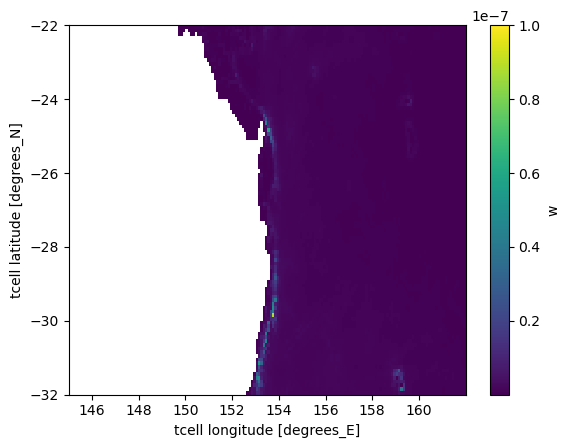

In [17]:
w_var_bran[0:14].mean(dim='sw_ocean').plot(vmax=1e-7)

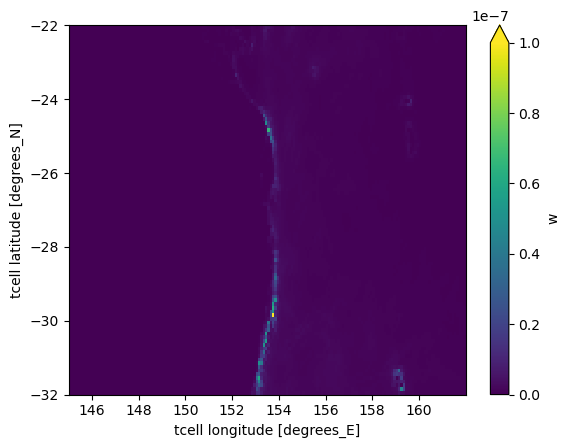

In [18]:
w_var_topX_bran.plot(vmax=1e-7)

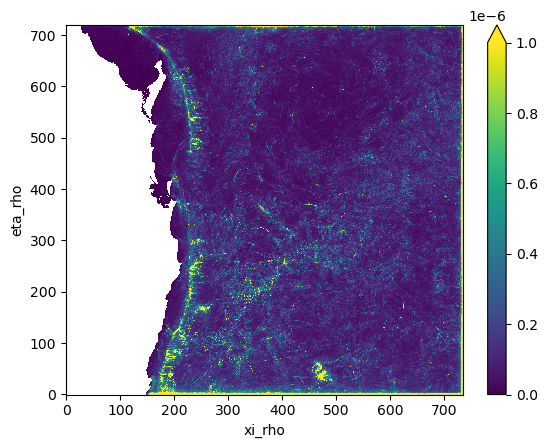

In [19]:
w_var_topX.plot(vmin=0,vmax=1e-6)

In [21]:
from matplotlib.colors import LogNorm

TypeError: Shapes of x (720, 735) and z (719, 734) do not match

<Figure size 640x480 with 0 Axes>

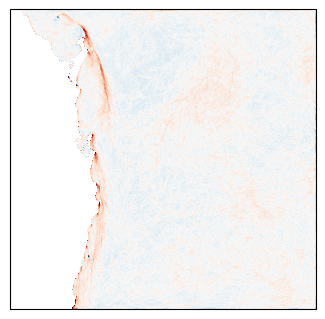

In [26]:
# snapshots of submeso diagnostics

plt.cla()
plt.clf()
fig = plt.figure(figsize=[12,9])
ax = None

gs = gridspec.GridSpec(nrows=2,ncols=3,wspace=0.02, hspace=0.02)

choose_depth=0
norm_logwvar=LogNorm(vmin=1e-10,vmax=1e-5)

# OUR MODEL

##### Ro number
ax=fig.add_subplot(gs[0,0],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,rel_vort_norm.mean(dim='ocean_time').isel(s_rho=-1),cmap='RdBu_r',vmin=-2,vmax=2)
# co = ax.contour(grd.lon_rho,grd.lat_rho,rel_vort_norm.mean(dim='ocean_time').isel(s_rho=-1),colors='k',linewidths=0.5,levels=[-1,1])

# co = ax.contour(grd.lon_rho,grd.lat_rho,rv_full.mean(dim='ocean_time').isel(s_w=-1),colors='k',linewidths=0.5,levels=[-1,1])

# ax.contour(grd.lon_psi,grd.lat_psi,rel_vort_norm.isel(s_rho=-1).isel(ocean_time=winter_period_snapshot).squeeze(),colors='k',linewidths=.5)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])
gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False

ax.text(0.02, 0.1, 'a', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))
# ax.text(0.019, 0.91, 'Ro', transform=ax.transAxes,fontsize=22, fontweight='normal', va='top')

central_lat = -27.5  # adjust for your map
scale_length_km = 30
deg_per_km = 1 / (111.32 * np.cos(np.radians(central_lat)))
scale_length_deg = scale_length_km * deg_per_km
lon0 = 152.7  # scale bar position
lat0 = -29.35
# Add scale bar
ax.plot([lon0, lon0 + scale_length_deg], [lat0, lat0],
        transform=ccrs.PlateCarree(), color='black', lw=4)
ax.text(lon0 + scale_length_deg / 2, lat0 - 0.002*lat0, '30 km',
        transform=ccrs.PlateCarree(), ha='center', va='bottom', fontsize=9)

# tt = ds.ocean_time.isel(ocean_time=period_snapshot_1).values[0]
# label = pd.to_datetime(tt).strftime('%B-%d')
# ax.set_title(label,fontsize=20)

##### strain
ax=fig.add_subplot(gs[0,1],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,strain_norm.isel(s_rho=-1).mean(dim='ocean_time').squeeze(),cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False
gl.left_labels = False

ax.text(0.02, 0.1, 'b', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))


##### <w'>
ax=fig.add_subplot(gs[0,2],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,w_var_topX,norm=norm_logwvar)#,cmap='cmo.rain_r',vmin=0,vmax=0.4e-3)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.left_labels = False
gl.bottom_labels = False
ax.text(0.02, 0.1, 'c', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))

# BRAN MODEL

##### Ro number
ax=fig.add_subplot(gs[1,0],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,zeta_norm.mean(dim='Time').isel(st_ocean=0),cmap='RdBu_r',vmin=-2,vmax=2)
# ax.contour(grd.lon_psi,grd.lat_psi,rel_vort_norm.isel(s_rho=-1).isel(ocean_time=winter_period_snapshot).squeeze(),colors='k',linewidths=.5)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])
gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True

ax.text(0.02, 0.1, 'd', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))
# ax.text(0.019, 0.91, 'Ro', transform=ax.transAxes,fontsize=22, fontweight='normal', va='top')

# central_lat = -27.5  # adjust for your map
# scale_length_km = 30
# deg_per_km = 1 / (111.32 * np.cos(np.radians(central_lat)))
# scale_length_deg = scale_length_km * deg_per_km
# lon0 = 152.6  # scale bar position
# lat0 = -30.3
# # Add scale bar
# ax.plot([lon0, lon0 + scale_length_deg], [lat0, lat0],
#         transform=ccrs.PlateCarree(), color='black', lw=4)
# ax.text(lon0 + scale_length_deg / 2, lat0 + 0.002*lat0, '30 km',
#         transform=ccrs.PlateCarree(), ha='center', va='top', fontsize=9)

# tt = ds.ocean_time.isel(ocean_time=period_snapshot_1).values[0]
# label = pd.to_datetime(tt).strftime('%B-%d')
# ax.set_title(label,fontsize=20)


cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.18,-0.13, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_xlabel(r'$\zeta/f$')#,fontsize=14)

##### strain
ax=fig.add_subplot(gs[1,1],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,strain_bran_norm.mean(dim='Time').isel(st_ocean=0),cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False

ax.text(0.02, 0.1, 'e', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))


cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.18,-0.13, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_xlabel(r'$|\mathbf{S}|/f$')#,fontsize=14)

##### <w'>
ax=fig.add_subplot(gs[1,2],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,w_var_topX_bran,norm=norm_logwvar)#,cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.left_labels = False

ax.text(0.02, 0.1, 'f', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))

cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.18,-0.13, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_xlabel(r"$ \overline{w'^2}$ (m$^2$/s$^2$)")#,fontsize=14)

######



In [ ]:
from matplotlib.colors import LogNorm

In [27]:
# interp the fields
# rel_vort_norm
rv_rho = 0.25 * (
    rel_vort_norm.isel(eta_v=slice(0, -1), xi_u=slice(0, -1)) +
    rel_vort_norm.isel(eta_v=slice(1, None), xi_u=slice(0, -1)) +
    rel_vort_norm.isel(eta_v=slice(0, -1), xi_u=slice(1, None)) +
    rel_vort_norm.isel(eta_v=slice(1, None), xi_u=slice(1, None))
)

In [28]:
rv_full = xr.full_like(ds.w[:,0:-1,:,:], np.nan)
rv_full[:,:,1:-1, 1:-1] = rv_rho

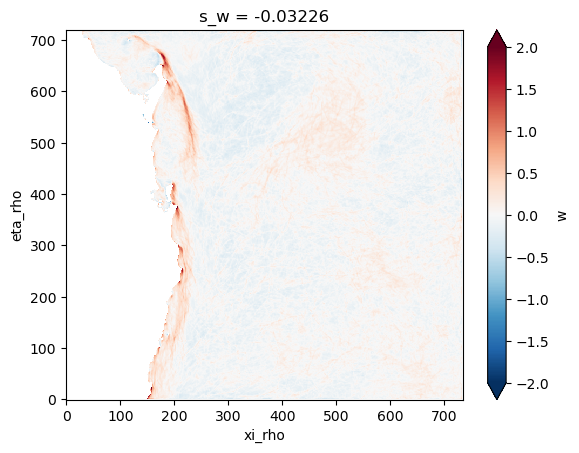

In [29]:
rv_full.mean(dim='ocean_time').isel(s_w=-1).plot(cmap='RdBu_r',vmin=-2,vmax=2)

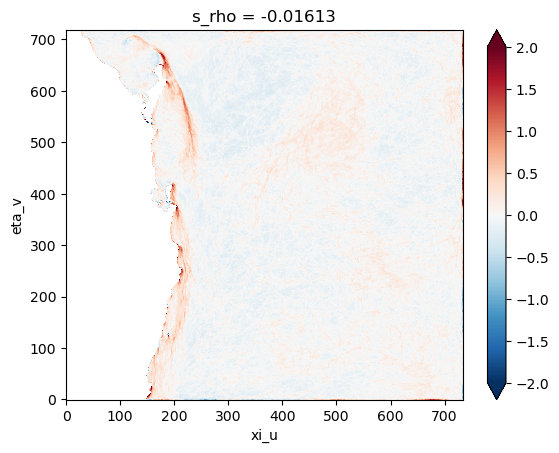

In [30]:
rel_vort_norm.mean(dim='ocean_time').isel(s_rho=-1).plot(cmap='RdBu_r',vmin=-2,vmax=2)

Text(0.5, 0, "$ \\overline{w'^2}$ (m$^2$/s$^2$)")

<Figure size 640x480 with 0 Axes>

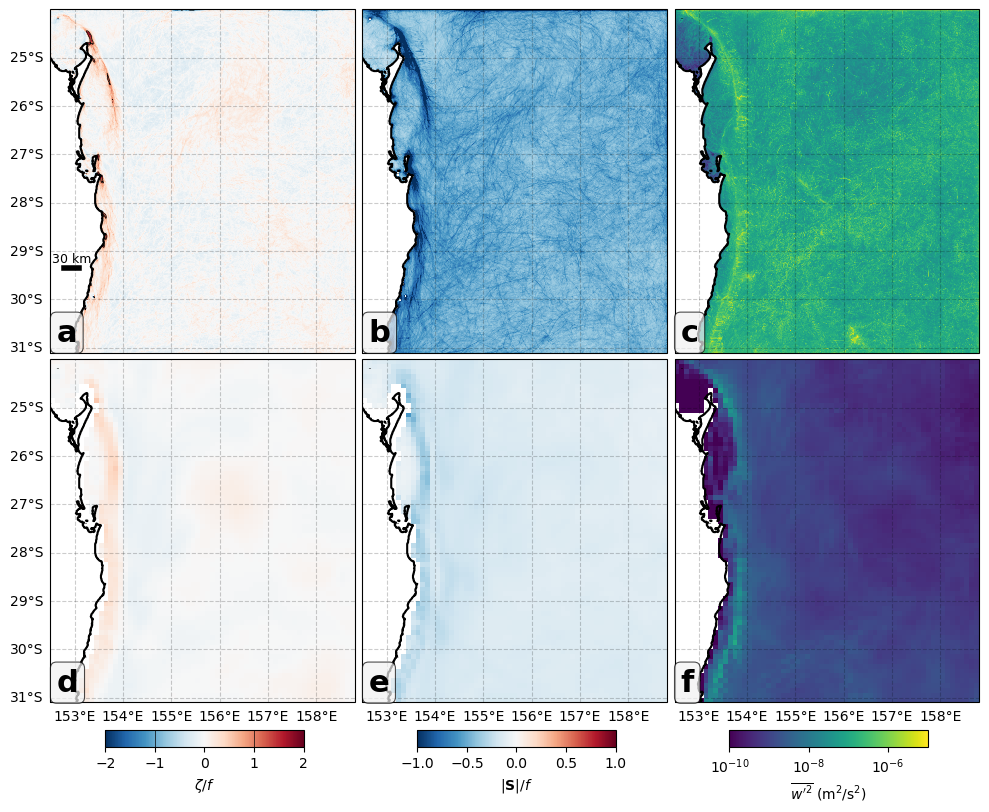

In [35]:
# snapshots of submeso diagnostics

plt.cla()
plt.clf()
fig = plt.figure(figsize=[12,9])
ax = None

gs = gridspec.GridSpec(nrows=2,ncols=3,wspace=0.02, hspace=0.02)

choose_depth=0
norm_logwvar=LogNorm(vmin=1e-10,vmax=1e-5)

# OUR MODEL

##### Ro number
ax=fig.add_subplot(gs[0,0],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,rel_vort_norm.mean(dim='ocean_time').isel(s_rho=-1),cmap='RdBu_r',vmin=-2,vmax=2)
co = ax.contour(grd.lon_rho,grd.lat_rho,rv_full.mean(dim='ocean_time').isel(s_w=-1),colors='k',linewidths=0.5,levels=[-1,1])

# ax.contour(grd.lon_psi,grd.lat_psi,rel_vort_norm.isel(s_rho=-1).isel(ocean_time=winter_period_snapshot).squeeze(),colors='k',linewidths=.5)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])
gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False

ax.text(0.02, 0.1, 'a', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))
# ax.text(0.019, 0.91, 'Ro', transform=ax.transAxes,fontsize=22, fontweight='normal', va='top')

central_lat = -27.5  # adjust for your map
scale_length_km = 30
deg_per_km = 1 / (111.32 * np.cos(np.radians(central_lat)))
scale_length_deg = scale_length_km * deg_per_km
lon0 = 152.79  # scale bar position
lat0 = -29.35
# Add scale bar
ax.plot([lon0, lon0 + scale_length_deg], [lat0, lat0],
        transform=ccrs.PlateCarree(), color='black', lw=4)
ax.text(lon0 + scale_length_deg / 2, lat0 - 0.002*lat0, '30 km',
        transform=ccrs.PlateCarree(), ha='center', va='bottom', fontsize=9)

# tt = ds.ocean_time.isel(ocean_time=period_snapshot_1).values[0]
# label = pd.to_datetime(tt).strftime('%B-%d')
# ax.set_title(label,fontsize=20)

##### strain
ax=fig.add_subplot(gs[0,1],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,strain_norm.isel(s_rho=-1).mean(dim='ocean_time').squeeze(),cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = False
gl.left_labels = False

ax.text(0.02, 0.1, 'b', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))


##### <w'>
ax=fig.add_subplot(gs[0,2],projection=ccrs.PlateCarree())
im = ax.pcolormesh(grd.lon_rho,grd.lat_rho,w_var_topX,norm=norm_logwvar)#,cmap='cmo.rain_r',vmin=0,vmax=0.4e-3)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.left_labels = False
gl.bottom_labels = False
ax.text(0.02, 0.1, 'c', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))

# BRAN MODEL

##### Ro number
ax=fig.add_subplot(gs[1,0],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,zeta_norm.mean(dim='Time').isel(st_ocean=0),cmap='RdBu_r',vmin=-2,vmax=2)
# ax.contour(grd.lon_psi,grd.lat_psi,rel_vort_norm.isel(s_rho=-1).isel(ocean_time=winter_period_snapshot).squeeze(),colors='k',linewidths=.5)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])
gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True

ax.text(0.02, 0.1, 'd', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))
# ax.text(0.019, 0.91, 'Ro', transform=ax.transAxes,fontsize=22, fontweight='normal', va='top')

# central_lat = -27.5  # adjust for your map
# scale_length_km = 30
# deg_per_km = 1 / (111.32 * np.cos(np.radians(central_lat)))
# scale_length_deg = scale_length_km * deg_per_km
# lon0 = 152.6  # scale bar position
# lat0 = -30.3
# # Add scale bar
# ax.plot([lon0, lon0 + scale_length_deg], [lat0, lat0],
#         transform=ccrs.PlateCarree(), color='black', lw=4)
# ax.text(lon0 + scale_length_deg / 2, lat0 + 0.002*lat0, '30 km',
#         transform=ccrs.PlateCarree(), ha='center', va='top', fontsize=9)

# tt = ds.ocean_time.isel(ocean_time=period_snapshot_1).values[0]
# label = pd.to_datetime(tt).strftime('%B-%d')
# ax.set_title(label,fontsize=20)


cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.18,-0.13, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cbar.add_lines(co)
cax.set_xlabel(r'$\zeta/f$')#,fontsize=14)

##### strain
ax=fig.add_subplot(gs[1,1],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,strain_bran_norm.mean(dim='Time').isel(st_ocean=0),cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False

ax.text(0.02, 0.1, 'e', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))


cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.18,-0.13, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_xlabel(r'$|\mathbf{S}|/f$')#,fontsize=14)

##### <w'>
ax=fig.add_subplot(gs[1,2],projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon,lat,w_var_topX_bran,norm=norm_logwvar)#,cmap='RdBu_r',vmin=-1,vmax=1)
ax.contour(grd.lon_rho,grd.lat_rho,grd.mask_rho,levels=[0],colors='k')
ax.set_extent([152.5, 158.81, -31.1, -24])

gl = ax.gridlines(draw_labels=True,
                    color='black', alpha=0.2, linestyle='--')
gl.right_labels = False
gl.top_labels = False
gl.left_labels = False

ax.text(0.02, 0.1, 'f', transform=ax.transAxes,fontsize=22, fontweight='bold', va='top',bbox=dict(boxstyle='round,pad=0.2',facecolor='0.95',edgecolor='black',linewidth=0.8,alpha=0.7))

cax = inset_axes(ax,
                width="65%",  # width = 10% of parent_bbox width
                height="5%",  # height : 50%
                loc='lower left',
                bbox_to_anchor=(0.18,-0.13, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0,
                )
cbar = fig.colorbar(im, cax=cax, orientation='horizontal') 
cax.set_xlabel(r"$ \overline{w'^2}$ (m$^2$/s$^2$)")#,fontsize=14)

######

